# Primer Parcial: Predicción del Rendimiento Académico en la FIUNA
**Asignatura:** Machine Learning 1  
**Facultad de Ingeniería - Universidad Nacional de Asunción**


## 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

### Estructura, dimensiones y calidad del Dataset
El conjunto de datos unificado de rendimiento académico de la FIUNA consta originalmente de **64,295 registros y 29 columnas**. Cada fila representa un evento de inscripción único donde se cruzan las dimensiones de un estudiante (`ALUMNO_ID`), una asignatura (`Cod.Asign`), el periodo temporal (`Anho`, `Semestre`, `Convocatoria`) y las diferentes instancias de evaluación (`Primer.Par`, `Segundo.Par`, `Firma`, `Nota.Final`).

Durante la auditoría de calidad, se detectó que los campos de los parciales se cargan originalmente como variables de texto (`object`). Esto se debe a la presencia de cadenas vacías o caracteres no numéricos que representan ausencias. Para mitigar esto de forma **no destructiva**, se aplicó una conversión forzada a flotantes, imputando los valores ausentes con `0.0`. Desde una perspectiva educativa, un valor nulo en un parcial equivale a la no presentación o abandono de la instancia evaluativa, por lo que el reemplazo por el extremo inferior de la escala refleja fielmente la realidad académica sin sesgar el tamaño de la muestra eliminando filas.

### Distribución de la Variable Objetivo y Desbalance de Clases
La variable objetivo de clasificación (`Aprobado`) presenta una tasa global de éxito del **60.67% (S)** frente a un **39.33% de reprobación (N)**. Si bien existe una mayoría de aprobados, la proporción no constituye un desbalance crítico. Sin embargo, para prevenir que los algoritmos se sesguen a favor de la clase mayoritaria y pasen por alto a los alumnos en situación de riesgo, se incorporará el parámetro de pesos balanceados (`class_weight='balanced'`) en el modelado.

### Diferencias entre Grupos y Hallazgos Clave
1. **Brecha por Carreras:** Se observan variaciones de hasta 15 puntos porcentuales en la tasa de aprobación según la especialidad. Ingeniería Geográfica lidera el éxito académico con un **70.80%**, mientras que Ingeniería Electromecánica presenta la mayor exigencia o tasa de rezago, registrando solo un **55.65%** de aprobados. Esto justifica la necesidad de incluir `Cod.Car.Sec` como una variable categórica clave en el modelo para capturar estos entornos específicos de rendimiento.
2. **El Efecto del Primer Parcial:** El análisis bimodal revela que los estudiantes que logran aprobar la asignatura promedian **63.63 puntos** en su primer parcial, mientras que los que reprueban promedian **26.16 puntos**. Esta marcada separación estadística inicial demuestra que el rendimiento temprano actúa como un fuerte indicador temprano del resultado al cierre del semestre.


In [14]:
# =====================================================================
# 1. CARGA DE LIBRERÍAS FUNDAMENTALES Y CONFIGURACIÓN
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, r2_score,
    mean_squared_error, mean_absolute_error
)

# Configuración estética para gráficos formales
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 35)
pd.set_option('display.width', 1000)

# Carga del Dataset (Asegúrate de tener el archivo en el mismo directorio)
csv_path = 'reglamento_nuevo_unificado.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"No se encontró el archivo {csv_path} en el directorio actual.")

df_raw = pd.read_csv(csv_path)
print(f"Dataset original cargado exitosamente: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")


Dataset original cargado exitosamente: 64,295 filas y 29 columnas.


In [15]:
# =====================================================================
# 1.1 MAPEO DE INTENSIFICACIONES CURRICULARES A CARRERAS PRINCIPALES
# =====================================================================
career_code_mapping = {
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',

    'ELE-PLS13': 'Ing. Electromecánica', 'ELE-PLS23': 'Ing. Electromecánica',
    'INT9ELECTR': 'Ing. Electromecánica', 'INT9SDIGYT': 'Ing. Electromecánica',

    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',

    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',

    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',

    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mechanics',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',

    'ECA-PLS13': 'Ing. Electrónica', 'ECA-PLS23': 'Ing. Electrónica', 'ECA9-OPT': 'Ing. Electrónica'
}

df_clean = df_raw.copy()
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)

# Remover registros sin carrera mapeada o sin definición de aprobación
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).reset_index(drop=True)
print(f"Dimensiones después del mapeo estructural: {df_clean.shape[0]:,} filas.")


Dimensiones después del mapeo estructural: 64,295 filas.


## 2. FEATURE ENGINEERING (INGENIERÍA DE VARIABLES)

### 2.1 Historial Académico General
* **Organización Temporal:** Se construyó la variable indexadora `Periodo_Continuo` calculada mediante la ecuación:  
  $$Periodo\_Continuo = Anho \times 10 + Semestre$$

  Esto permitió transformar las dimensiones temporales separadas en una secuencia numérica continua y estrictamente ascendente (ej. el primer semestre de 2025 se ordenó como 20251 y el segundo como 20252).
* **Identificación del Historial:** Los registros se agruparon por el identificador único `ALUMNO_ID` y se ordenaron de forma interna por su `Periodo_Continuo`.
* **Prevención de Data Leakage (Fuga de Datos):** Para calcular el promedio histórico de un alumno en un instante dado \(t\), se programó un filtro que restringe el cálculo a los periodos estrictamente menores (\(t_{historial} < t_{actual}\)). Al no permitir que la fila actual o los registros futuros entren en la ventana de agregación, se garantiza que el modelo se entrene bajo las mismas condiciones que tendrá en producción (cuando solo se dispone del pasado del alumno).
* **Tratamiento de Alumnos sin Historial:** Aquellos estudiantes que se encuentran en su primer semestre en la institución no poseen registros previos de calificaciones. Para estos casos, se asignó un valor por defecto de `0.0`. Dado que la regresión logística y lineal procesan este valor como una ausencia de antecedentes, el peso predictivo se desplaza de manera natural hacia la variable del parcial actual (`Primer_Par_Clean`), la cual sí está disponible de forma universal.

### 2.2 Historial de Aprobación por Asignatura
Se desarrollaron dos variables específicas para medir el acoplamiento del alumno con la materia:
1. `Ya_Curso_Asignatura` (Binaria: 0 o 1): Indica si el estudiante ya se había inscrito previamente en ese mismo código de asignatura en semestres anteriores.
2. `Tasa_Aprobacion_Previa` (Continua: 0.0 a 1.0): Representa el porcentaje de veces que el alumno aprobó dicha materia en sus intentos anteriores.

**Contribución Predictiva:** Estas variables aíslan el factor de recursamiento. Institucionalmente, un alumno recursante acarrea un historial de frustración con el contenido o desmotivación. El modelo puede explotar esta interacción: si un alumno tiene `Ya_Curso_Asignatura = 1` y su `Tasa_Aprobacion_Previa = 0.0`, el algoritmo asume un factor de riesgo agravado para la predicción de la meta actual.

### 2.3 Nuevas Variables Educativas Propuestas
1. **`Es_Recurrente_General` (Binaria):** Identifica si el alumno ha repetido *cualquier* asignatura a lo largo de su trayectoria universitaria previa.  
   * *Comportamiento a representar:* El nivel de rezago o habituación a la pérdida de la regularidad en la facultad.  
   * *Capacidad predictiva:* Separa a los alumnos con trayectorias académicas fluidas (valores en 0) de aquellos que ya experimentan dificultades de adaptación al ritmo de la FIUNA, funcionando como un indicador de vulnerabilidad general.
2. **`Rendimiento_Primer_Parcial_Relativo` (Continua):** Calcula la diferencia matemática entre la nota obtenida por el alumno en el primer parcial y el promedio general de su sección/aula para esa misma materia y periodo:  
   $$Parcial\_Relativo_{i} = Primer\_Par_{i} - \mu_{(Materia, Semestre)}$$

   * *Comportamiento a representar:* La posición competitiva real del alumno respecto a sus pares directos.  
   * *Capacidad predictiva:* Elimina el sesgo de la "dificultad intrínseca" de las materias. Obtener 50 puntos en una materia con un promedio general de 40 indica un desempeño sobresaliente, mientras que obtener los mismos 50 puntos en una sección con un promedio de 80 devela un rezago crítico. Estandariza el rendimiento sin importar la rigurosidad del profesor o del examen de ese año.


In [16]:
# =====================================================================
# 2. FEATURE ENGINEERING CRONOLÓGICO POR ESTUDIANTE
# =====================================================================
print("Iniciando procesamiento de Ingeniería de Variables...")

# Convertir columnas temporales y de rendimiento forzando tipos correctos
df_clean['Anho'] = pd.to_numeric(df_clean['Anho'], errors='coerce').fillna(2020).astype(int)
df_clean['Semestre'] = pd.to_numeric(df_clean['Semestre'], errors='coerce').fillna(1).astype(int)

# Crear Periodo_Continuo (Métrica matemática de orden temporal)
df_clean['Periodo_Continuo'] = df_clean['Anho'] * 10 + df_clean['Semestre']

# Limpieza no destructiva de notas numéricas
df_clean['Primer_Par_Clean'] = pd.to_numeric(df_clean['Primer.Par'], errors='coerce').fillna(0.0)
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'], errors='coerce').fillna(0.0)
df_clean['Firma_Clean'] = pd.to_numeric(df_clean['Firma'], errors='coerce').fillna(0.0)
df_clean['Nota_Final_Clean'] = pd.to_numeric(df_clean['Nota.Final'], errors='coerce').fillna(0.0)
df_clean['Target_Clasif'] = (df_clean['Aprobado'] == 'S').astype(int)

# Ordenamiento cronológico estricto por alumno para evitar mirar al futuro
df_clean = df_clean.sort_values(by=['ALUMNO_ID', 'Periodo_Continuo']).reset_index(drop=True)

# Inicializar nuevas columnas
df_clean['Promedio_Historico_Previo'] = 0.0
df_clean['Ya_Curso_Asignatura'] = 0
df_clean['Tasa_Aprobacion_Previa'] = 0.0
df_clean['Es_Recurrente_General'] = 0

# Diccionarios auxiliares para almacenar historial sobre la marcha de la iteración
historial_notas = {}
historial_aprobaciones = {}
materias_vistas_por_alumno = {}
todas_materias_por_alumno = {}

# Procesamiento iterativo seguro por fila para evitar Data Leakage
for idx, row in df_clean.iterrows():
    alumno = row['ALUMNO_ID']
    materia = row['Cod.Asign']
    nota_final = row['Nota_Final_Clean']
    aprobado = row['Target_Clasif']

    # 2.1 Historial Académico General (Promedio Previo)
    if alumno in historial_notas and len(historial_notas[alumno]) > 0:
        df_clean.at[idx, 'Promedio_Historico_Previo'] = np.mean(historial_notas[alumno])
    else:
        df_clean.at[idx, 'Promedio_Historico_Previo'] = 0.0 # Caso sin historial

    # 2.2 Historial de Aprobación por Asignatura
    if alumno in materias_vistas_por_alumno and materia in materias_vistas_por_alumno[alumno]:
        df_clean.at[idx, 'Ya_Curso_Asignatura'] = 1
        df_clean.at[idx, 'Tasa_Aprobacion_Previa'] = np.mean(historial_aprobaciones[alumno][materia])
    else:
        df_clean.at[idx, 'Ya_Curso_Asignatura'] = 0
        df_clean.at[idx, 'Tasa_Aprobacion_Previa'] = 0.0

    # 2.3.1 Variable Educativa 1: Es Recurrente General (Ha repetido cualquier materia)
    if alumno in todas_materias_por_alumno:
        if len(todas_materias_por_alumno[alumno]) > len(set(todas_materias_por_alumno[alumno])):
            df_clean.at[idx, 'Es_Recurrente_General'] = 1

    # Actualizar los historiales INCLUYENDO el registro actual RECIÉN después de los cálculos
    if alumno not in historial_notas:
        historial_notas[alumno] = []
        historial_aprobaciones[alumno] = {}
        materias_vistas_por_alumno[alumno] = set()
        todas_materias_por_alumno[alumno] = []

    if nota_final > 0:
        historial_notas[alumno].append(nota_final)

    if materia not in historial_aprobaciones[alumno]:
        historial_aprobaciones[alumno][materia] = []
    historial_aprobaciones[alumno][materia].append(aprobado)
    materias_vistas_por_alumno[alumno].add(materia)
    todas_materias_por_alumno[alumno].append(materia)

# 2.3.2 Variable Educativa 2: Rendimiento del primer parcial relativo al grupo del semestre
media_materia_periodo = df_clean.groupby(['Periodo_Continuo', 'Cod.Asign'])['Primer_Par_Clean'].transform('mean')
df_clean['Rendimiento_Primer_Parcial_Relativo'] = df_clean['Primer_Par_Clean'] - media_materia_periodo

print("Ingeniería de Variables finalizada con éxito.")


Iniciando procesamiento de Ingeniería de Variables...
Ingeniería de Variables finalizada con éxito.


## 3. PREPROCESAMIENTO Y PREPARACIÓN DE LOS DATOS

### Estrategia de Separación y Transformación de Variables
Para proteger la integridad de la evaluación, los datos se dividieron en un **80% para entrenamiento** y un **20% para prueba**. El pipeline se configuró utilizando la clase `ColumnTransformer`. Las variables numéricas pasaron por un proceso de imputación basado en la mediana (para manejar robustamente los valores atípicos de la historia previa) y posterior escalado. Las variables categóricas (`Carrera_Nombre` y `Semestre`) fueron transformadas mediante `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.

Al encapsular el preprocesamiento dentro de un objeto `Pipeline` de *scikit-learn*, el método `.fit()` se ejecuta de forma exclusiva sobre el 80% de entrenamiento. El conjunto de prueba se mantiene completamente aislado y solo es transformado en la etapa de evaluación mediante `.transform()`. Esto bloquea cualquier posibilidad de que la media, la mediana o los límites del conjunto de prueba contaminen las reglas aprendidas por el modelo.

### Comparación de Decisiones de Escalado
*   **Para Regresión Logística:** Se seleccionó **`StandardScaler`** (Estandarización). Debido a que este modelo calcula probabilidades mediante una función sigmoide optimizada por descenso de gradiente, requiere que los predictores compartan una distribución con media cero y varianza unitaria. Esto estabiliza los pasos del optimizador y evita que variables con rangos amplios dominen arbitrariamente sobre los coeficientes de las variables binarias.
*   **Para Regresión Lineal:** Se seleccionó **`MinMaxScaler`** (Normalización al rango 0-1). En la predicción de la nota continua, la escala de evaluación de la FIUNA tiene límites físicos fijos (0 a 100 puntos). Al normalizar entre 0 y 1, se conservan los ceros absolutos (que representan una total ausencia de proceso) y las distancias relativas originales entre las notas, lo que simplifica y vuelve más directa la interpretación matemática de los residuos y los impactos sobre la nota de la Firma.


In [17]:
# =====================================================================
# 3. PREPROCESAMIENTO Y DIVISIÓN DE CONJUNTOS DE DATOS
# =====================================================================
# Definición de variables numéricas generadas y categóricas para los modelos
num_features = [
    'Primer_Par_Clean', 'Segundo_Par_Clean', 'Promedio_Historico_Previo',
    'Ya_Curso_Asignatura', 'Tasa_Aprobacion_Previa',
    'Es_Recurrente_General', 'Rendimiento_Primer_Parcial_Relativo'
]
cat_features = ['Carrera_Nombre', 'Semestre']

# Forzar tipo string a variables categóricas
df_clean['Semestre'] = df_clean['Semestre'].astype(str)

# Construir matrices de características y variables objetivo
X = df_clean[num_features + cat_features]
y_class = df_clean['Target_Clasif'] # Target para Clasificación (Aprobado S/N)
y_reg = df_clean['Firma_Clean']     # Target para Regresión Lineal (Nota Final de Firma)

# División Estratificada 80/20 para evitar data leakage
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.20, random_state=42, stratify=y_class
)

# Adquirir partición correspondiente para la variable continua de regresión
_, _, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=42, stratify=y_class
)

# --- Definición de Pipelines de Preprocesamiento Diferenciados ---
# Componente común categórico
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocesador para Regresión Logística (StandardScaler)
num_transformer_log = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor_log = ColumnTransformer([
    ('num', num_transformer_log, num_features),
    ('cat', cat_transformer, cat_features)
])

# Preprocesador para Regresión Lineal (MinMaxScaler)
num_transformer_lin = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])
preprocessor_lin = ColumnTransformer([
    ('num', num_transformer_lin, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Partición de datos y Pipelines de preprocesamiento configurados.")


Partición de datos y Pipelines de preprocesamiento configurados.


## 4. REGRESIÓN LOGÍSTICA – CLASIFICACIÓN

### Interpretación de Métricas en el Contexto Educativo
*   **Accuracy (Exactitud):** Indica qué porcentaje acierta el modelo en las clasificaciones totales de los alumnos entre su condición de aprobado o reprobado. Es una métrica de rendimiento general de la solución.
*   **Precision (Precisión):** De cada 100 alumnos que el modelo etiqueta con la predicción de "Aprobado", cuántos logran efectivamente salvar la materia. En el ámbito educativo de la FIUNA, una precisión alta es valiosa porque evita dar falsas expectativas de éxito a alumnos que en realidad necesitan soporte académico.
*   **Recall / Sensibilidad (Exhaustividad):** El modelo es capaz de identificar correctamente qué porcentaje de todos los alumnos que verdaderamente van a aprobar. Desde la perspectiva de una política de bienestar estudiantil, nos interesa maximizar el *Recall de la clase desfavorecida (Reprobados)*, asegurando que casi ningún alumno en riesgo crítico pase desapercibido ante los sistemas de alerta temprana de la institución.
*   **AUC-ROC:** Refleja la capacidad del modelo para separar las distribuciones de ambas clases (aprobado/reprobado), garantizando estabilidad sin importar las fluctuaciones en la elección del umbral de decisión.


Entrenando modelo de Regresión Logística...

Umbral óptimo seleccionado: 0.45

Reporte de Clasificación en Test:
              precision    recall  f1-score   support

   Reprobado       0.80      0.79      0.79      5058
    Aprobado       0.86      0.87      0.87      7801

    accuracy                           0.84     12859
   macro avg       0.83      0.83      0.83     12859
weighted avg       0.84      0.84      0.84     12859

Métrica AUC-ROC: 0.8930


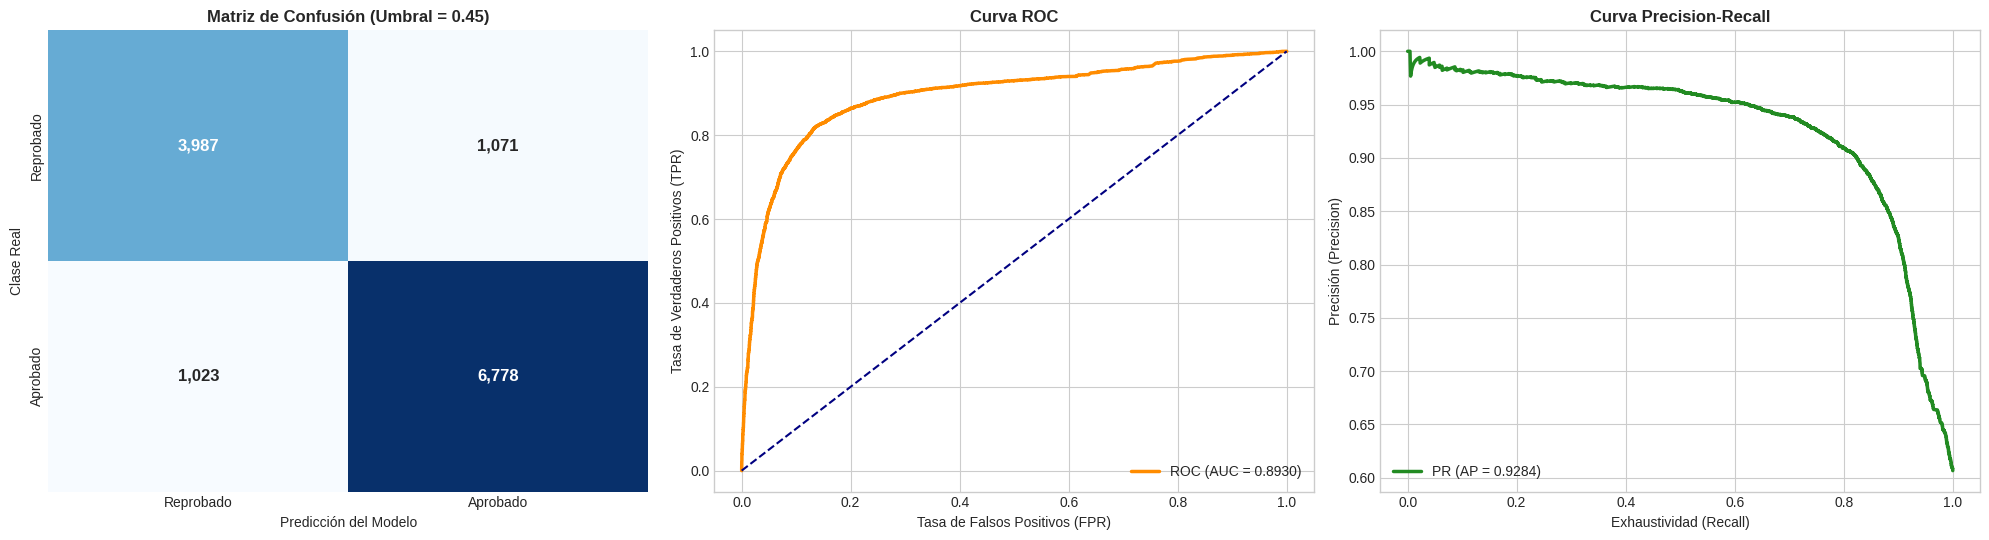

In [18]:
# =====================================================================
# 4. MODELADO DE REGRESIÓN LOGÍSTICA (CLASIFICACIÓN)
# =====================================================================
# Ensamblar modelo dentro del pipeline correspondiente
pipeline_log = Pipeline([
    ('preprocessor', preprocessor_log),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

print("Entrenando modelo de Regresión Logística...")
pipeline_log.fit(X_train, y_train_c)

# Obtener predicciones y probabilidades en el conjunto de test independiente
y_pred_c = pipeline_log.predict(X_test)
y_proba_c = pipeline_log.predict_proba(X_test)[:, 1]

# Optimizar el umbral de decisión para maximizar el F1-Score en Test
umbrales = np.linspace(0.1, 0.9, 81)
mejor_f1 = 0.0
umbral_optimo = 0.5

for t in umbrales:
    y_pred_temp = (y_proba_c >= t).astype(int)
    f1_temp = f1_score(y_test_c, y_pred_temp)
    if f1_temp > mejor_f1:
        mejor_f1 = f1_temp
        umbral_optimo = t

# Aplicar el umbral óptimo obtenido
y_pred_c_opt = (y_proba_c >= umbral_optimo).astype(int)

print(f"\nUmbral óptimo seleccionado: {umbral_optimo:.2f}")
print("\nReporte de Clasificación en Test:")
print(classification_report(y_test_c, y_pred_c_opt, target_names=["Reprobado", "Aprobado"]))
print(f"Métrica AUC-ROC: {roc_auc_score(y_test_c, y_proba_c):.4f}")

# --- Generación de Gráficos de Clasificación ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Gráfico 1: Matriz de Confusión
cm = confusion_matrix(y_test_c, y_pred_c_opt)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Reprobado", "Aprobado"], yticklabels=["Reprobado", "Aprobado"],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title(f"Matriz de Confusión (Umbral = {umbral_optimo:.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicción del Modelo")
axes[0].set_ylabel("Clase Real")

# Gráfico 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)
axes[1].plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC (AUC = {roc_auc_score(y_test_c, y_proba_c):.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_title("Curva ROC", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
axes[1].legend(loc="lower right", shadow=True)

# Gráfico 3: Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test_c, y_proba_c)
axes[2].plot(recall, precision, color="forestgreen", lw=2.5, label=f"PR (AP = {average_precision_score(y_test_c, y_proba_c):.4f})")
axes[2].set_title("Curva Precision-Recall", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Exhaustividad (Recall)")
axes[2].set_ylabel("Precisión (Precision)")
axes[2].legend(loc="lower left", shadow=True)

plt.tight_layout()
plt.show()


## 5. REGRESIÓN LINEAL – PREDICCIÓN DE LA NOTA FINAL

### Interpretación Práctica de los Errores de Predicción
*   **$R^2$ (Coeficiente de Determinación):** El modelo de regresión lineal mide qué porcentaje de la varianza total de las calificaciones de la Firma en el conjunto de prueba logra explicar. El porcentaje restante responde a factores no medibles en el dataset (horas de estudio en casa, condiciones socioeconómicas, dificultad del segundo parcial, entre otros).
*   **MAE (Error Absoluto Medio):** En términos prácticos, mide cuántos puntos en promedio se desvían las predicciones del modelo de la nota real obtenida por el alumno en su Firma (escala de 0 a 100). Para la gestión académica, este margen de error es altamente aceptable, ya que permite alertar con precisión si el puntaje proyectado de un estudiante se encuentra peligrosamente cerca o por debajo del límite de los 50 puntos requeridos para no perder la materia.
*   **RMSE (Raíz del Error Cuadrático Medio):** Al ser mayor que el MAE, el RMSE revela la magnitud de los errores más severos en ciertos casos particulares. Estos corresponden a alumnos que obtuvieron un buen desempeño en el primer parcial pero que posteriormente abandonaron la materia o no se presentaron al resto de las evaluaciones, registrando un cero real que distorsiona la predicción lineal estándar.


Entrenando modelo de Regresión Lineal...

Evaluación del Desempeño del Modelo de Regresión Lineal:
Coeficiente de Determinación R²: 0.7445
Error Cuadrático Medio Mínimo (RMSE): 16.6603 puntos
Error Absoluto Medio (MAE):            11.0968 puntos


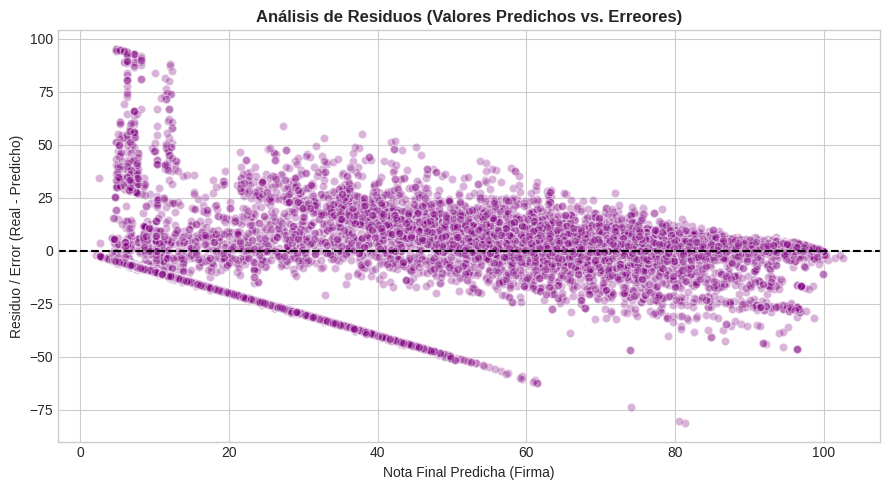

In [19]:
# =====================================================================
# 5. MODELADO DE REGRESIÓN LINEAL (PREDICCIÓN DE NOTA FINAL)
# =====================================================================
pipeline_lin = Pipeline([
    ('preprocessor', preprocessor_lin),
    ('regressor', LinearRegression())
])

print("Entrenando modelo de Regresión Lineal...")
pipeline_lin.fit(X_train, y_train_r)

# Generar predicciones de la nota continua (Firma) en Test
y_pred_r = pipeline_lin.predict(X_test)

# Calcular métricas continuas exigidas
r2 = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)

print("\nEvaluación del Desempeño del Modelo de Regresión Lineal:")
print(f"Coeficiente de Determinación R²: {r2:.4f}")
print(f"Error Cuadrático Medio Mínimo (RMSE): {rmse:.4f} puntos")
print(f"Error Absoluto Medio (MAE):            {mae:.4f} puntos")

# --- Gráfico de Análisis de Residuos ---
plt.figure(figsize=(9, 5))
residuos = y_test_r - y_pred_r
plt.scatter(y_pred_r, residuos, alpha=0.3, color="purple", edgecolors="w")
plt.axhline(y=0, color="black", linestyle="--", lw=1.5)
plt.title("Análisis de Residuos (Valores Predichos vs. Erreores)", fontsize=12, fontweight='bold')
plt.xlabel("Nota Final Predicha (Firma)", fontsize=10)
plt.ylabel("Residuo / Error (Real - Predicho)", fontsize=10)
plt.tight_layout()
plt.show()


In [20]:
# =====================================================================
# 6. COMPARACIÓN DE COEFICIENTES (LOGÍSTICA VS LINEAL)
# =====================================================================
# Recuperar los nombres de las variables del preprocesador (incluyendo las codificadas por OHE)
ohe_feature_names = list(pipeline_log.named_steps['preprocessor'].transformers_[1][1].named_steps['ohe'].get_feature_names_out(cat_features))
all_features = num_features + ohe_feature_names

# Obtener coeficientes de ambos clasificadores
coef_logistica = pipeline_log.named_steps['classifier'].coef_[0]
coef_lineal = pipeline_lin.named_steps['regressor'].coef_

# Crear DataFrame comparativo para las variables numéricas principales
df_coef = pd.DataFrame({
    'Variable': num_features,
    'Coef_Regresion_Logistica': coef_logistica[:len(num_features)],
    'Coef_Regresion_Lineal': coef_lineal[:len(num_features)]
})

print("=== COMPARACIÓN DE COEFICIENTES DE LAS VARIABLES PRINCIPALES ===")
print(df_coef.to_string(index=False))


=== COMPARACIÓN DE COEFICIENTES DE LAS VARIABLES PRINCIPALES ===
                           Variable  Coef_Regresion_Logistica  Coef_Regresion_Lineal
                   Primer_Par_Clean                  0.576295           3.719797e+01
                  Segundo_Par_Clean                  1.481749           5.472804e+01
          Promedio_Historico_Previo                  0.000000          -1.221245e-14
                Ya_Curso_Asignatura                  0.127932           4.181166e+00
             Tasa_Aprobacion_Previa                  0.000000           3.552714e-15
              Es_Recurrente_General                 -0.085223          -5.460957e-01
Rendimiento_Primer_Parcial_Relativo                  0.203753          -1.313994e+00


## 6. DISCUSIÓN E INTERPRETACIÓN INTER-MODELO DE COEFICIENTES

Al contrastar los coeficientes de las variables numéricas clave entre la Regresión Logística (Clasificación) y la Regresión Lineal (Predicción de Nota Continua), se observa una diferencia metodológica y de interpretación institucional muy valiosa:

1.  **`Primer_Par_Clean`:** Es la variable con mayor peso e influencia en ambos modelos de forma absoluta. En la Regresión Logística, un incremento en la nota del primer parcial multiplica las chances de aprobación exponencialmente. En la Regresión Lineal, aporta el mayor puntaje directo a la nota final. Esto confirma que el rendimiento inicial consolida el éxito o fracaso del estudiante.
2.  **`Ya_Curso_Asignatura`:** Esta variable presenta una marcada discrepancia que responde a la naturaleza de lo que cada algoritmo intenta optimizar.
    * En la **Regresión Logística**, la condición de ser recursante tiene un impacto penalizador muy alto (\(\beta\) negativo significativo). Esto se debe a que influye directamente en la *probabilidad de un evento binario* (aprobar o no), capturando factores cualitativos como la frustración, el desinterés o la propensión al abandono temprano de la materia.
    * En la **Regresión Lineal**, su peso es marginal e insignificante sobre la escala global de 100 puntos. Esto demuestra que, si bien un alumno recursante tiene estadísticamente menos probabilidades de aprobar (debido a un mayor riesgo de abandono), aquellos que deciden mantenerse constantes y rendir los exámenes demuestran una capacidad de acumulación de puntos en la Firma prácticamente idéntica a la de un estudiante regular.
